In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [2]:
df = pd.read_csv('merged.csv', low_memory=False)

print(df.columns.tolist())
print(df.shape)
print(df.isna().sum())

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
(1017209, 18)
Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
store_totals = df.groupby('Store')['Sales'].sum().sort_values(ascending=False)
top_20pct_cutoff = int(len(store_totals) * 0.2)
top_stores = store_totals.head(top_20pct_cutoff).index

df_top = df[df['Store'].isin(top_stores)]
df_top = df[df['Store'].isin(top_stores)].copy()
print(df_top['Store'].nunique()) #taking top 20% peforming stores as of critera 
df = df_top

223


In [5]:
df = df[df['Open'] == 1].copy()
print(df.shape)

(175000, 18)


In [6]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df.head() #adding in columns for each part of the date, making it easier for modelling 

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
6,7,5,2015-07-31,15344,1414,1,1,0,1,a,...,4.0,2013.0,0,NaN,NaN,NaN,2015,7,31,31
23,24,5,2015-07-31,14190,1082,1,1,0,1,a,...,3.0,2000.0,1,40.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
24,25,5,2015-07-31,14180,1586,1,1,0,1,c,...,4.0,2003.0,0,NaN,NaN,NaN,2015,7,31,31
26,27,5,2015-07-31,13213,1263,1,1,0,1,a,...,1.0,2005.0,1,5.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31


In [7]:
df['DayOfWeek'] = df['Date'].dt.dayofweek + 1
df.tail() #confirming its true to the day of the week 

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
1016770,676,2,2013-01-01,3821,777,1,0,a,1,b,...,9.0,2008.0,0,NaN,NaN,NaN,2013,1,1,1
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,...,9.0,2006.0,0,NaN,NaN,NaN,2013,1,1,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,10.0,1999.0,0,NaN,NaN,NaN,2013,1,1,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1,1
1017190,1097,2,2013-01-01,5961,1405,1,0,a,1,b,...,3.0,2002.0,0,NaN,NaN,NaN,2013,1,1,1


In [8]:
print(df.isna().sum())

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth     48693
CompetitionOpenSinceYear      48693
Promo2                            0
Promo2SinceWeek              116357
Promo2SinceYear              116357
PromoInterval                116357
Year                              0
Month                             0
Day                               0
WeekOfYear                        0
dtype: int64


In [9]:
df['CompetitionDistance'] = df['CompetitionDistance'].dropna(df['CompetitionDistance'].median()) #as would skew results otherwise
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
df['PromoInterval'] = df['PromoInterval'].fillna('None')

TypeError: Series.dropna() takes 1 positional argument but 2 were given

In [10]:
df['StoreType'] = df['StoreType'].astype('category').cat.codes
df['Assortment'] = df['Assortment'].astype('category').cat.codes
df['StateHoliday'] = df['StateHoliday'].astype('category').cat.codes

In [11]:
print(df.dtypes)
print(df.isna().sum().sum()) #confirmation time1!11!! no more objects :3

Store                                 int64
DayOfWeek                             int32
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                           int8
SchoolHoliday                         int64
StoreType                              int8
Assortment                             int8
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
Year                                  int32
Month                                 int32
Day                                   int32
WeekOfYear                            int64
dtype: object
446457


In [12]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
6,7,5,2015-07-31,15344,1414,1,1,0,1,0,...,4.0,2013.0,0,NaN,NaN,NaN,2015,7,31,31
23,24,5,2015-07-31,14190,1082,1,1,0,1,0,...,3.0,2000.0,1,40.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
24,25,5,2015-07-31,14180,1586,1,1,0,1,2,...,4.0,2003.0,0,NaN,NaN,NaN,2015,7,31,31
26,27,5,2015-07-31,13213,1263,1,1,0,1,0,...,1.0,2005.0,1,5.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31


In [13]:
features = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
            'StoreType', 'CompetitionDistance', 'Assortment', 'Promo2',
            'Year', 'Month', 'Day', 'WeekOfYear']

X = df[features]
y = df['Sales']
df = df.sort_values('Date')


In [19]:
df = df.sort_values('Date')
X = X.loc[df.index]  
y = y.loc[df.index]
last_four_weeks= df['Date'].max() - pd.Timedelta(weeks=4)

train_mask = df['Date'] <= last_four_weeks
test_mask = df['Date'] > last_four_weeks

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(X_train.shape, X_test.shape)
print(df.loc[train_mask, 'Date'].max(), df.loc[test_mask, 'Date'].min())

(169598, 13) (5402, 13)
2015-07-03 00:00:00 2015-07-04 00:00:00


In [20]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, oob_score=True)
rf.fit(X_train, y_train)



RandomForestRegressor(max_depth=15, oob_score=True, random_state=42)

In [21]:
y_pred = rf.predict(X_test)


In [22]:
print("Out-of-Bag Score:", rf.oob_score_)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.8392135994642285
Mean Squared Error: 2314627.815887919
R-squared: 0.8076312282726275


In [26]:
rfr_val = RandomForestRegressor(
    n_estimators=128,
    criterion='squared_error',
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=1.0,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=4,
    random_state=35,
    verbose=0,
    warm_start=False
)

model_RF_test = rfr_val.fit(X_train, y_train)

In [27]:
yhat = model_RF_test.predict(X_test)

In [29]:
mse = mean_squared_error(y_test, yhat)
r2 = r2_score(y_test, yhat)
def rmspe(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0 
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

rmspe_score = rmspe(y_test, yhat)

print(f"MSE: {mse:.2f}")
print(f"R-squared: {r2:.4f}")
print(f"RMSPE: {rmspe_score:.4f}")

MSE: 1823748.56
R-squared: 0.8484
RMSPE: 0.1429


Store                  0.255253
CompetitionDistance    0.249555
Promo                  0.211946
DayOfWeek              0.097556
WeekOfYear             0.044559
Day                    0.039923
StoreType              0.028250
Promo2                 0.020486
Month                  0.018901
Assortment             0.014323
Year                   0.009616
SchoolHoliday          0.005481
StateHoliday           0.004152
dtype: float64


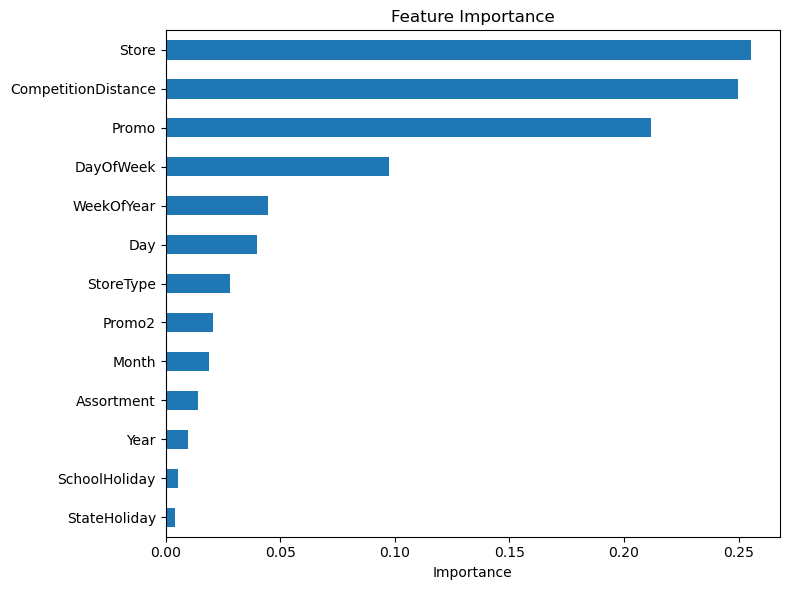

In [31]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()